In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("diabetes.csv")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

df.info()

Dataset Shape: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [2]:
#https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [3]:
display(df.describe().T)

# Tıbben imkansız 0 değerlerine sahip hedef sütunların tanımlanması
biological_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Sentetik eksik veri (0) metriklerinin sütun bazlı hesaplanması
zero_analysis = pd.DataFrame({
    "Zero_Count": (df[biological_features] == 0).sum(),
    "Zero_Ratio (%)": np.round(((df[biological_features] == 0).sum() / len(df)) * 100, 2)
})

print("--- Biological Feature Missing Value Analysis ---")
display(zero_analysis.sort_values(by="Zero_Ratio (%)", ascending=False))

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


--- Biological Feature Missing Value Analysis ---


,Zero_Count,Zero_Ratio (%)
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


,Count,Percentage (%)
Outcome,,
0,500,65.1
1,268,34.9


C:\Users\musta\AppData\Local\Temp\ipykernel_34032\1699388618.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Outcome", ax=ax, palette=["#2ecc71", "#e74c3c"])
C:\Users\musta\AppData\Local\Temp\ipykernel_34032\1699388618.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Negative (0)", "Positive (1)"])


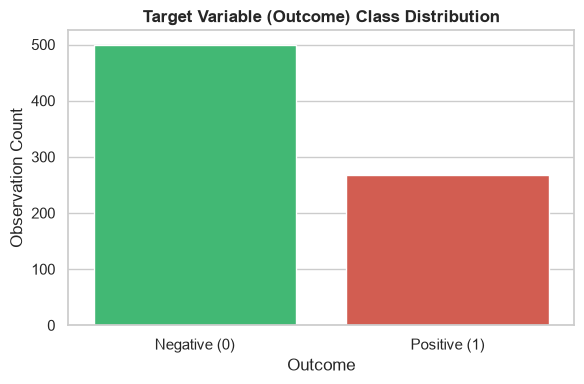

In [4]:
# Hedef değişken mutlak ve oransal dağılımı
class_counts = df["Outcome"].value_counts()
class_ratios = df["Outcome"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": np.round(class_ratios, 2)
})
display(class_summary)

# Dağılımın görselleştirilmesi
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Outcome", ax=ax, palette=["#2ecc71", "#e74c3c"])
ax.set_title("Target Variable (Outcome) Class Distribution", fontsize=12, fontweight="bold")
ax.set_xticklabels(["Negative (0)", "Positive (1)"])
ax.set_ylabel("Observation Count")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"X_train Shape: {X_train.shape} | y_train Class Ratio (1s): {y_train.mean():.2%}")
print(f"X_test Shape : {X_test.shape}  | y_test Class Ratio (1s) : {y_test.mean():.2%}")

X_train Shape: (614, 8) | y_train Class Ratio (1s): 34.85%
X_test Shape : (154, 8)  | y_test Class Ratio (1s) : 35.06%


In [6]:
biological_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Train ve Test setlerinde bağımsız olarak 0 -> NaN dönüşümü
X_train[biological_features] = X_train[biological_features].replace(0, np.nan)
X_test[biological_features] = X_test[biological_features].replace(0, np.nan)

# Train setindeki NaN dağılımı kontrolü
print("--- X_train Missing Values (NaN) Count ---")
print(X_train[biological_features].isnull().sum())

--- X_train Missing Values (NaN) Count ---
Glucose            4
BloodPressure     23
SkinThickness    175
Insulin          290
BMI                9
dtype: int64


In [7]:
# 1. Yalnızca Train verisi ve y_train birleştirilerek koşullu medyan matrisi hesaplanır
train_temp = X_train.copy()
train_temp["Outcome"] = y_train

# Sınıf bazlı (Outcome=0 ve Outcome=1) medyanların hesaplanması
conditional_medians = train_temp.groupby("Outcome")[biological_features].median()

print("--- Calculated Medians from Train Set (By Outcome) ---")
display(conditional_medians)

# 2. X_train üzerindeki NaN değerlerin doldurulması
for col in biological_features:
    for outcome_val in [0, 1]:
        median_val = conditional_medians.loc[outcome_val, col]
        # Train doldurma
        train_idx = (X_train[col].isnull()) & (y_train == outcome_val)
        X_train.loc[train_idx, col] = median_val
        
        # Test doldurma (Train'den öğrenilen medyan uygulanır)
        test_idx = (X_test[col].isnull()) & (y_test == outcome_val)
        X_test.loc[test_idx, col] = median_val

# Islah sonrası NaN kontrolü
print("\nMissing values remaining in X_train:", X_train.isnull().sum().sum())
print("Missing values remaining in X_test :", X_test.isnull().sum().sum())

--- Calculated Medians from Train Set (By Outcome) ---


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
Outcome,,,,,
0,108.0,70.0,27.0,100.0,30.10
1,141.5,76.0,33.0,168.0,34.35



Missing values remaining in X_train: 0
Missing values remaining in X_test : 0


In [8]:
def create_engineered_features(df_input):
    df_out = df_input.copy()
    
    # 1. Glucose / Insulin Oranı (Metabolik Verimlilik Indeksi)
    # Sıfıra bölünme hatasını önlemek için epsilon (1e-6) eklenebilir veya doğrudan oranlanır
    df_out["Glucose_Insulin_Ratio"] = df_out["Glucose"] / (df_out["Insulin"] + 1e-6)
    
    # 2. BMI Segmentasyonu (WHO Standartları)
    df_out["BMI_Category"] = pd.cut(
        df_out["BMI"],
        bins=[0, 18.5, 24.9, 29.9, 34.9, 39.9, 100],
        labels=["Underweight", "Normal", "Overweight", "Obesity_1", "Obesity_2", "Obesity_3"]
    )
    
    # 3. Yaş Gruplaması
    df_out["Age_Group"] = pd.cut(
        df_out["Age"],
        bins=[20, 30, 45, 100],
        labels=["Young", "Middle_Aged", "Senior"]
    )
    
    # 4. Kan Basıncı Riski (Sistolik/Diyastolik Basit Risk Indeksi)
    df_out["BP_Risk"] = pd.cut(
        df_out["BloodPressure"],
        bins=[0, 80, 89, 200],
        labels=["Normal", "Prehypertension", "Hypertension"]
    )
    
    return df_out

# Fonksiyonun Train ve Test kümesine bağımsız uygulanması
X_train_fe = create_engineered_features(X_train)
X_test_fe  = create_engineered_features(X_test)

# Kategorik Değişkenlerin One-Hot Encoding (OHE) Yapılması
categorical_cols = ["BMI_Category", "Age_Group", "BP_Risk"]

X_train_fe = pd.get_dummies(X_train_fe, columns=categorical_cols, drop_first=True, dtype=int)
X_test_fe  = pd.get_dummies(X_test_fe, columns=categorical_cols, drop_first=True, dtype=int)

# Train ve Test sütunlarının birebir aynı sıraya ve sayıda olduğundan emin olunması
X_train_fe, X_test_fe = X_train_fe.align(X_test_fe, join="left", axis=1, fill_value=0)

print(f"Yeni Feature Sayısı (X_train): {X_train_fe.shape[1]}")
display(X_train_fe.head(3))

Yeni Feature Sayısı (X_train): 18


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_Insulin_Ratio,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obesity_1,BMI_Category_Obesity_2,BMI_Category_Obesity_3,Age_Group_Middle_Aged,Age_Group_Senior,BP_Risk_Prehypertension,BP_Risk_Hypertension
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24,2.093023,0,1,0,0,0,0,0,0,0
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40,5.727272,0,1,0,0,0,1,0,0,0
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25,1.117021,0,0,1,0,0,0,0,0,0


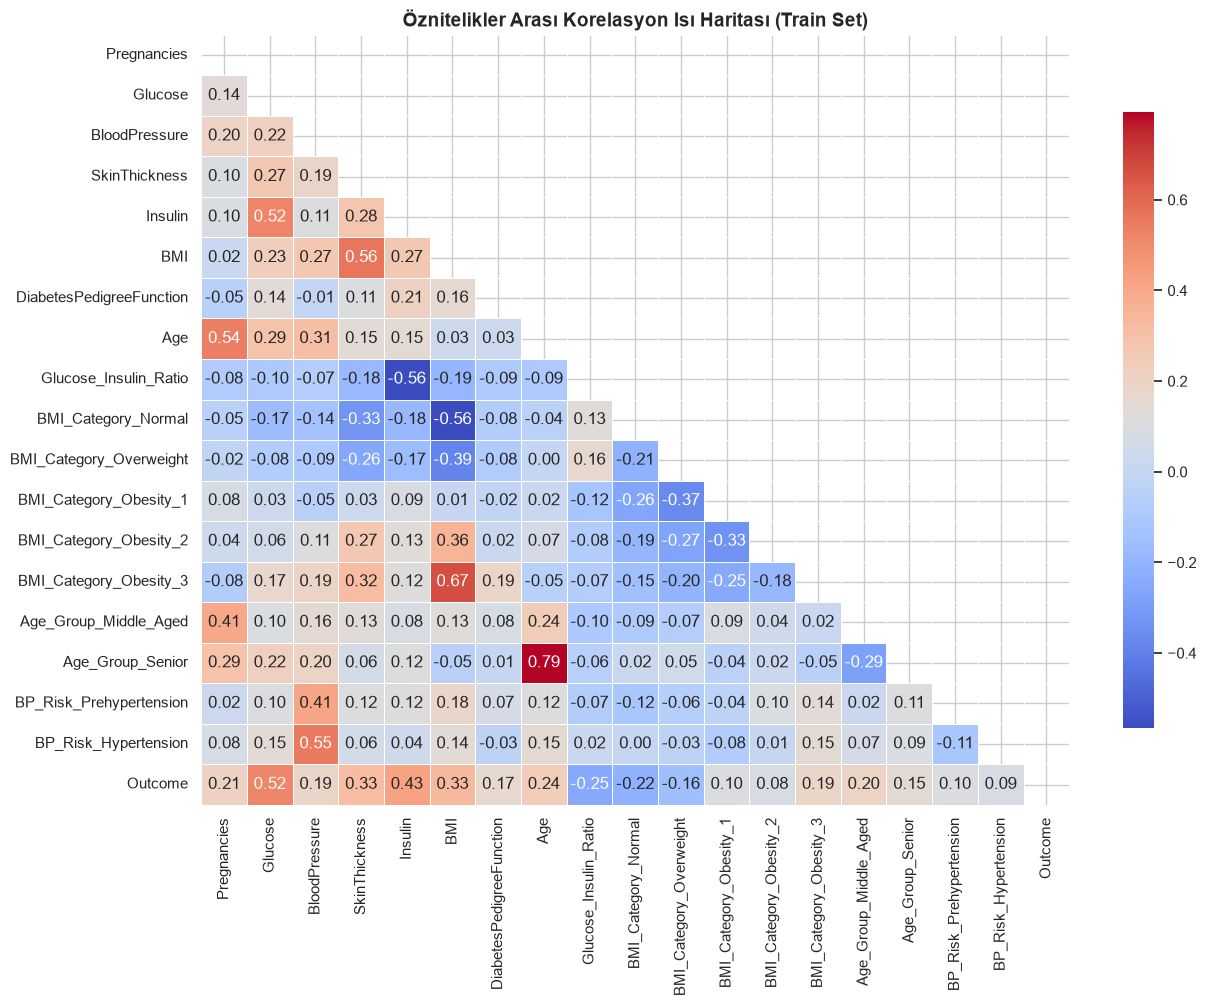

--- Outcome İle En Yüksek Korelasyona Sahip Öznitelikler ---
Glucose                  0.516144
Insulin                  0.426472
BMI                      0.332595
SkinThickness            0.325407
Age                      0.240676
Pregnancies              0.208173
Age_Group_Middle_Aged    0.196815
BloodPressure            0.193464
Name: Outcome, dtype: float64


In [9]:
# Train kümesi ve y_train birleştirilerek korelasyon analizi yapılır
train_corr = X_train_fe.copy()
train_corr["Outcome"] = y_train.values

# Korelasyon Matrisi
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(train_corr.corr(), dtype=bool)) # Üst üçgeni gizlemek için maske

sns.heatmap(
    train_corr.corr(), 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title("Öznitelikler Arası Korelasyon Isı Haritası (Train Set)", fontsize=14, fontweight="bold")
plt.show()

# Outcome ile en yüksek korelasyona sahip ilk 8 öznitelik
top_correlations = train_corr.corr()["Outcome"].sort_values(ascending=False)[1:9]
print("--- Outcome İle En Yüksek Korelasyona Sahip Öznitelikler ---")
print(top_correlations)

C:\Users\musta\AppData\Local\Temp\ipykernel_34032\910739535.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_corr, x="Outcome", y="Glucose_Insulin_Ratio", palette=["#2ecc71", "#e74c3c"], ax=axes[1, 0])
C:\Users\musta\AppData\Local\Temp\ipykernel_34032\910739535.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_corr, x="Outcome", y="Age", palette=["#2ecc71", "#e74c3c"], ax=axes[1, 1])


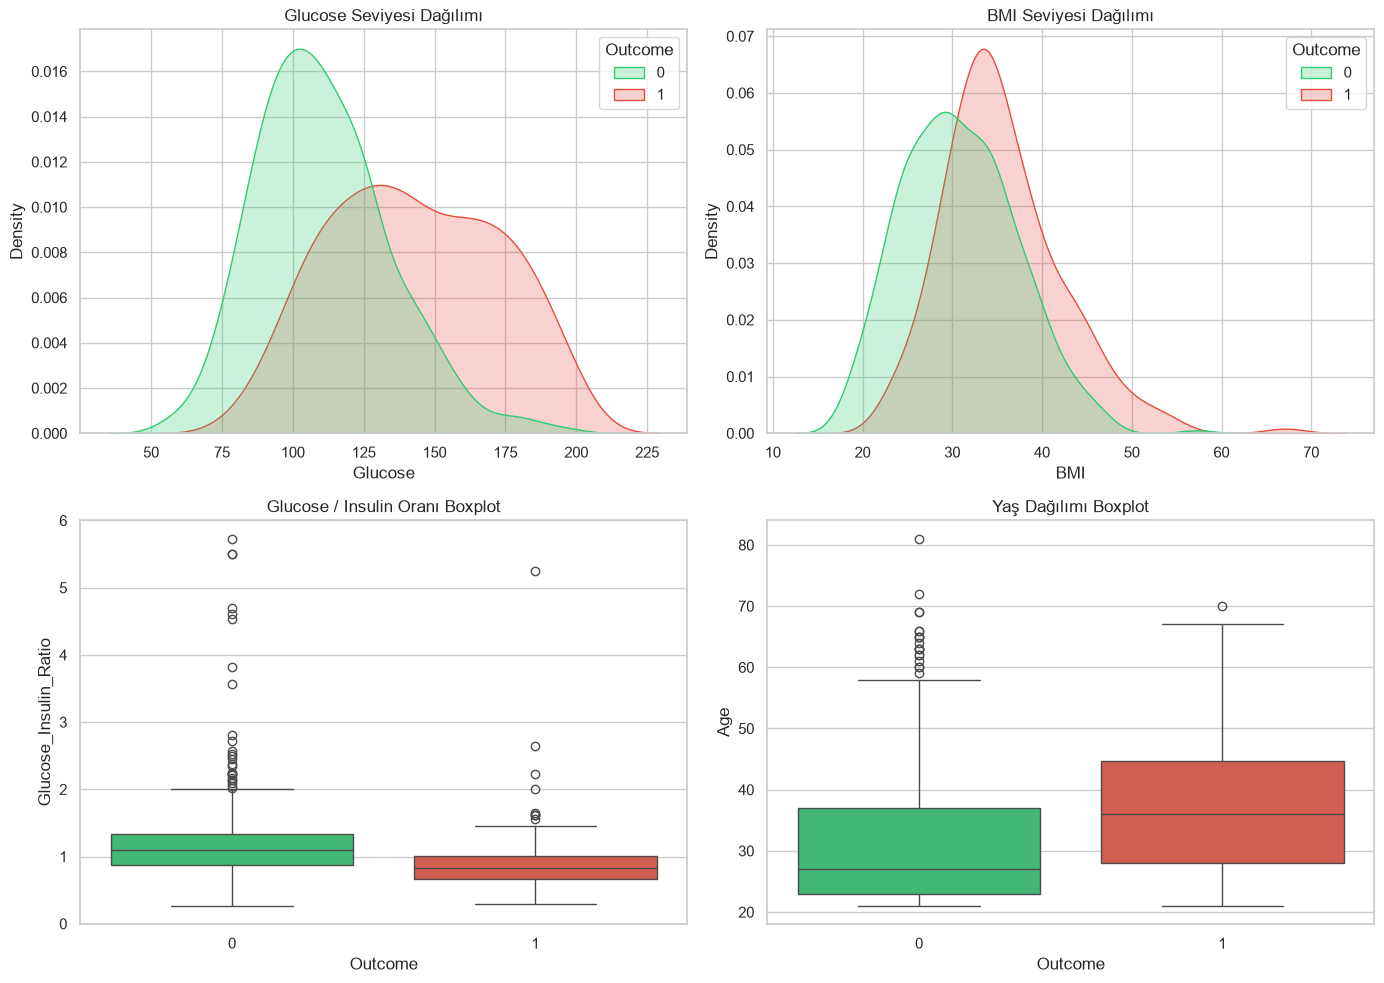

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Glucose Dağılımı
sns.kdeplot(data=train_corr, x="Glucose", hue="Outcome", fill=True, common_norm=False, palette=["#2ecc71", "#e74c3c"], ax=axes[0, 0])
axes[0, 0].set_title("Glucose Seviyesi Dağılımı")

# 2. BMI Dağılımı
sns.kdeplot(data=train_corr, x="BMI", hue="Outcome", fill=True, common_norm=False, palette=["#2ecc71", "#e74c3c"], ax=axes[0, 1])
axes[0, 1].set_title("BMI Seviyesi Dağılımı")

# 3. Glucose / Insulin Ratio Boxplot
sns.boxplot(data=train_corr, x="Outcome", y="Glucose_Insulin_Ratio", palette=["#2ecc71", "#e74c3c"], ax=axes[1, 0])
axes[1, 0].set_title("Glucose / Insulin Oranı Boxplot")

# 4. Age Dağılımı
sns.boxplot(data=train_corr, x="Outcome", y="Age", palette=["#2ecc71", "#e74c3c"], ax=axes[1, 1])
axes[1, 1].set_title("Yaş Dağılımı Boxplot")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Kullanılacak Sınıflandırma Algoritmalarının İçe Aktarılması
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Modellerin Tanımlanması (Baseline Parametreler - XGBoost ve LightGBM Hariç)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 2. Cross-Validation Stratejisi (5-Fold Stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Değerlendirme Metrikleri
scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# 4. Modellerin Eğitilmesi ve Metrik İstatistiklerinin Derlenmesi
results = []

for name, model in models.items():
    # Pipeline: robust scaling + classifier entegrasyonu
    pipeline = Pipeline([
        ("scaler", RobustScaler()),
        ("classifier", model)
    ])
    
    cv_results = cross_validate(
        pipeline, X_train_fe, y_train, 
        cv=cv, scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1-Score": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean()
    })

# Sonuçların DataFrame Yapısına Dönüştürülmesi
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("--- Baseline Model Cross-Validation Performans Tablosu (Train Set) ---")
display(results_df.style.background_gradient(cmap="Blues", subset=["Recall", "F1-Score", "ROC-AUC"]))

--- Baseline Model Cross-Validation Performans Tablosu (Train Set) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.872931,0.835123,0.794463,0.813329,0.938168
1,SVC,0.861509,0.804970,0.799003,0.800704,0.915393
2,Logistic Regression,0.833826,0.796049,0.705426,0.746654,0.890759
3,KNN,0.832214,0.773655,0.738538,0.754399,0.883616


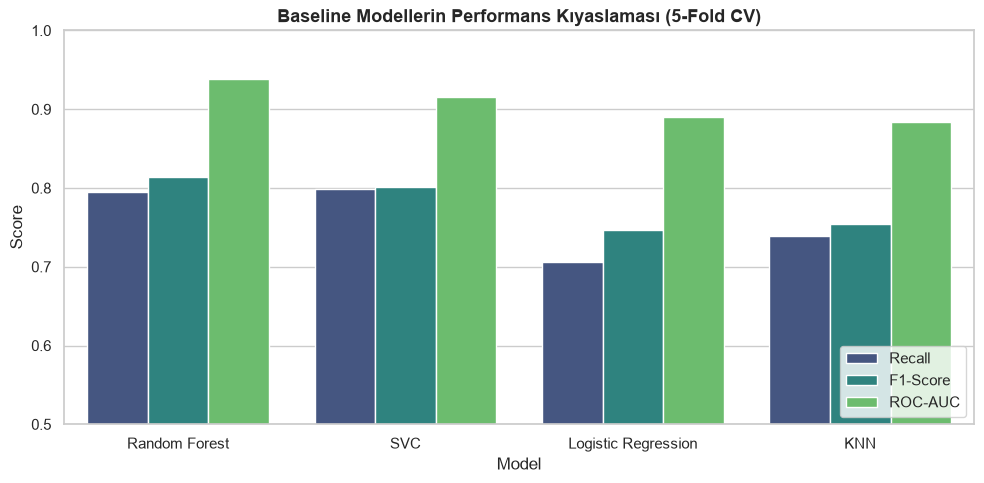

In [12]:
plt.figure(figsize=(10, 5))

# Long-format dönüşümü
results_melted = results_df.melt(id_vars="Model", value_vars=["Recall", "F1-Score", "ROC-AUC"], 
                                  var_name="Metric", value_name="Score")

sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Baseline Modellerin Performans Kıyaslaması (5-Fold CV)", fontsize=13, fontweight="bold")
plt.ylim(0.5, 1.0)
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

# 1. LOGISTIC REGRESSION HYPERPARAMETER TUNING
log_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

grid_log = GridSearchCV(
    log_pipeline, 
    param_grid=log_param_grid, 
    cv=cv, 
    scoring="roc_auc", 
    n_jobs=-1
)

grid_log.fit(X_train_fe, y_train)

print("--- Logistic Regression En İyi Parametreler ---")
print(grid_log.best_params_)
print(f"En İyi CV ROC-AUC Skoru: {grid_log.best_score_:.4f}")

--- Logistic Regression En İyi Parametreler ---
{'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
En İyi CV ROC-AUC Skoru: 0.8912


C:\Users\musta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
# 2. RANDOM FOREST HYPERPARAMETER TUNING
rf_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [4, 6, 8, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__criterion": ["gini", "entropy"]
}

grid_rf = GridSearchCV(
    rf_pipeline, 
    param_grid=rf_param_grid, 
    cv=cv, 
    scoring="roc_auc", 
    n_jobs=-1
)

grid_rf.fit(X_train_fe, y_train)

print("\n--- Random Forest En İyi Parametreler ---")
print(grid_rf.best_params_)
print(f"En İyi CV ROC-AUC Skoru: {grid_rf.best_score_:.4f}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, PrecisionRecallDisplay

# 1. En İyi Modellerin Seçilmesi
best_log_model = grid_log.best_estimator_
best_rf_model = grid_rf.best_estimator_

# 2. Test Kümesi Üzerinde Tahminlerin Alınması (Sınıf Etiketleri ve Olasılıklar)
y_pred_log = best_log_model.predict(X_test_fe)
y_proba_log = best_log_model.predict_proba(X_test_fe)[:, 1]

y_pred_rf = best_rf_model.predict(X_test_fe)
y_proba_rf = best_rf_model.predict_proba(X_test_fe)[:, 1]

# 3. Test ROC-AUC Skorlarının Hesaplanması
test_auc_log = roc_auc_score(y_test, y_proba_log)
test_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=" * 60)
print(f"Logistic Regression - Test ROC-AUC Skoru: {test_auc_log:.4f}")
print("=" * 60)
print(classification_report(y_test, y_pred_log, target_names=["Sağlıklı (0)", "Diyabet (1)"]))

print("=" * 60)
print(f"Random Forest - Test ROC-AUC Skoru: {test_auc_rf:.4f}")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=["Sağlıklı (0)", "Diyabet (1)"]))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["Sağlıklı (0)", "Diyabet (1)"], yticklabels=["Sağlıklı (0)", "Diyabet (1)"])
axes[0].set_title(f"Logistic Regression Confusion Matrix\n(Test AUC: {test_auc_log:.3f})")
axes[0].set_xlabel("Tahmin Edilen (Predicted)")
axes[0].set_ylabel("Gerçek Değer (Actual)")

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False,
            xticklabels=["Sağlıklı (0)", "Diyabet (1)"], yticklabels=["Sağlıklı (0)", "Diyabet (1)"])
axes[1].set_title(f"Random Forest Confusion Matrix\n(Test AUC: {test_auc_rf:.3f})")
axes[1].set_xlabel("Tahmin Edilen (Predicted)")
axes[1].set_ylabel("Gerçek Değer (Actual)")

plt.tight_layout()
plt.show()

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {test_auc_log:.3f})", color="#2980b9", lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {test_auc_rf:.3f})", color="#27ae60", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Rastgele Tahmin (AUC = 0.500)")

plt.xlabel("False Positive Rate (Yanlış Pozitif Oranı)")
plt.ylabel("True Positive Rate (Doğru Pozitif Oranı / Recall)")
plt.title("Test Kümesi ROC-AUC Eğrileri Kıyaslaması", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [ ]:
# Random Forest modelinden öznitelik önem düzeylerinin alınması
rf_classifier = best_rf_model.named_steps["classifier"]
importances = rf_classifier.feature_importances_
feature_names = X_train_fe.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest - En Önemli İlk 10 Öznitelik (Feature Importance)", fontsize=13, fontweight="bold")
plt.xlabel("Göreceli Önem Derecesi")
plt.ylabel("Öznitelik")
plt.tight_layout()
plt.show()